In [1]:
import pandas as pd 
import numpy as np 
from sqlalchemy import create_engine 

engine = create_engine (
    "postgresql://postgres@localhost:5432/fintech_db"
)

#veriyi yükle 
df=pd.read_sql("SELECT * FROM islemler", engine )
print(df.shape)
df.head()

    


(10, 5)


,islem_id,musteri_id,tutar,kategori,durum
0,1,1,1500.0,Alışveriş,onaylı
1,2,2,320.0,Fatura,onaylı
2,3,3,8900.0,Transfer,beklemede
3,4,1,450.0,Fatura,onaylı
4,5,4,12000.0,Transfer,iptal


In [2]:
# Kategori bazında çoklu hesaplama
ozet = df.groupby('kategori').agg(
    islem_sayisi = ('tutar', 'count'),
    toplam_tutar = ('tutar', 'sum'),
    ort_tutar    = ('tutar', 'mean'),
    max_tutar    = ('tutar', 'max')
).round(2)

ozet

,islem_sayisi,toplam_tutar,ort_tutar,max_tutar
kategori,,,,
Alışveriş,4,4765.0,1191.25,2200.0
Fatura,3,1350.0,450.00,580.0
Transfer,3,24200.0,8066.67,12000.0


In [3]:
# Müşteriler tablosu
musteriler = pd.DataFrame({
    'musteri_id': [1, 2, 3, 4, 5],
    'ad':         ['Ahmet', 'Ayşe', 'Mehmet', 'Zeynep', 'Can'],
    'sehir':      ['İstanbul', 'Ankara', 'İstanbul', 'İzmir', 'Bursa']
})

musteriler

,musteri_id,ad,sehir
0,1,Ahmet,İstanbul
1,2,Ayşe,Ankara
2,3,Mehmet,İstanbul
3,4,Zeynep,İzmir
4,5,Can,Bursa


In [4]:
 pd.merge(musteriler , df , on='musteri_id', how='left')

,musteri_id,ad,sehir,islem_id,tutar,kategori,durum
0,1,Ahmet,İstanbul,1.0,1500.0,Alışveriş,onaylı
1,1,Ahmet,İstanbul,4.0,450.0,Fatura,onaylı
2,1,Ahmet,İstanbul,9.0,3300.0,Transfer,onaylı
3,2,Ayşe,Ankara,2.0,320.0,Fatura,onaylı
4,2,Ayşe,Ankara,6.0,75.0,Alışveriş,onaylı
5,3,Mehmet,İstanbul,3.0,8900.0,Transfer,beklemede
6,3,Mehmet,İstanbul,7.0,2200.0,Alışveriş,onaylı
7,4,Zeynep,İzmir,5.0,12000.0,Transfer,iptal
8,4,Zeynep,İzmir,8.0,580.0,Fatura,onaylı
9,4,Zeynep,İzmir,10.0,990.0,Alışveriş,beklemede


In [5]:
birlestir.groupby('sehir').agg(
    
    toplam_tutar = ('tutar', 'sum')
)

NameError: name 'birlestir' is not defined

In [ ]:
birlestir.groupby('sehir').agg(
    ort_tutar =('tutar', 'mean'),
    toplam_tutar = ('tutar', 'sum'),
    musteri_sayisi = ('musteri_id' , 'count')
)

In [ ]:
pivot = pd.pivot_table(
    df,
    values  = 'tutar',
    index   = 'kategori',
    columns = 'durum',
    aggfunc = 'sum',
    fill_value = 0
)
pivot

In [ ]:

print("Ortalama:", df['tutar'].mean().round(2))
print("Medyan:  ", df['tutar'].median())
print("Std:     ", df['tutar'].std().round(2))

In [ ]:
df.groupby('durum')['tutar'].agg(['mean', 'median', 'std']).round(2)

In [ ]:
# Yeni sütunlar ekle
df['gun'] = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14]  # ay içindeki gün
df['islem_suresi'] = [2, 1, 5, 1, 3, 1, 2, 1, 4, 2]  # dakika

# Korelasyon matrisi
df[['tutar', 'gun', 'islem_suresi']].corr().round(2)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(df['tutar'], bins=5, color='#378ADD', edgecolor='white')
plt.title('İşlem Tutarı Dağılımı')
plt.xlabel('Tutar (TL)')
plt.ylabel('İşlem Sayısı')
plt.show()

In [ ]:
plt.figure(figsize=(6, 4))
plt.boxplot(df['tutar'], vert=False)
plt.title('Tutar Box Plot — Aykırı Değer Tespiti')
plt.xlabel('Tutar (TL)')
plt.show()

In [ ]:
Q1 = df['tutar'].quantile(0.25)
Q3 = df['tutar'].quantile(0.75)
IQR = Q3 - Q1

alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

print(f"Alt sınır: {alt_sinir}")
print(f"Üst sınır: {ust_sinir}")

# Aykırı değerler
aykirı = df[df['tutar'] > ust_sinir]
print("\nAykırı işlemler:")
aykirı[['musteri_id', 'tutar', 'kategori']]

## Gün 3 — Plotly ile İnteraktif Grafikler


In [ ]:
import plotly.express as px
import plotly.graph_objects as go

In [ ]:
fig = px.histogram(
    df,
    x     = 'tutar',
    color = 'kategori',
    title = 'İşlem Tutarı Dağılımı — Kategoriye Göre',
    nbins = 10
)
fig.show()

In [ ]:
kategori_ozet = df.groupby('kategori')['tutar'].sum().reset_index()

fig = px.bar(
    kategori_ozet,
    x     = 'kategori',
    y     = 'tutar',
    color = 'kategori',
    title = 'Kategori Bazında Toplam Tutar',
    text  = 'tutar'
)
fig.show()

In [6]:
fig = px.scatter(
    df,
    x     = 'islem_suresi',
    y     = 'tutar',
    color = 'kategori',
    size  = 'tutar',
    hover_data = ['musteri_id'],
    title = 'İşlem Süresi vs Tutar'
)
fig.show()


NameError: name 'px' is not defined

In [7]:
import plotly.express as px
import plotly.graph_objects as go

df['gun'] = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
df['islem_suresi'] = [2, 1, 5, 1, 3, 1, 2, 1, 4, 2]

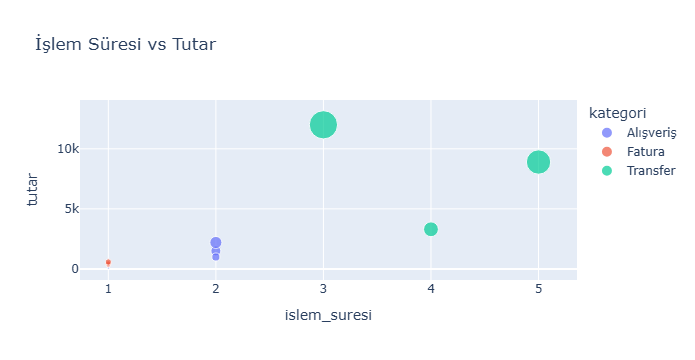

In [8]:
fig = px.scatter(
    df,
    x     = 'islem_suresi',
    y     = 'tutar',
    color = 'kategori',
    size  = 'tutar',
    hover_data = ['musteri_id'],
    title = 'İşlem Süresi vs Tutar'
)
fig.show()

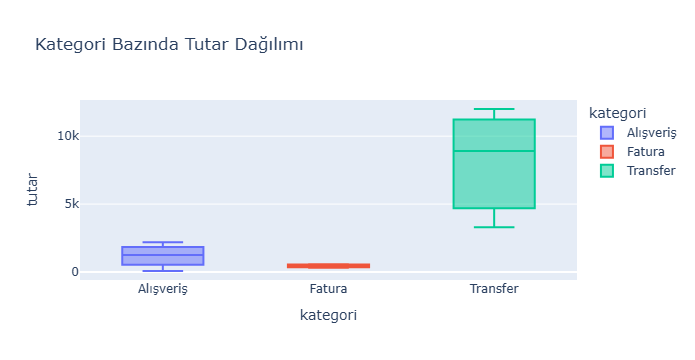

In [9]:
fig = px.box(
    df,
    x     = 'kategori',
    y     = 'tutar',
    color = 'kategori',
    title = 'Kategori Bazında Tutar Dağılımı'
)
fig.show()